# 03 — Strategy Comparison: TWAP vs VWAP vs Almgren-Chriss

1,000 Monte Carlo scenarios per strategy — comparison of cost distributions (IS), VaR 95%, CVaR 95%, and position on the efficient frontier.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from src.almgren_chriss import AlmgrenChrissModel
from src.simulator import ExecutionSimulator

plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
COLORS = {'Almgren-Chriss': 'steelblue', 'TWAP': 'seagreen', 'VWAP': 'tomato'}
N_SIMS  = 1_000
SEED    = 42
print(f'✓ Imports OK — {N_SIMS:,} simulations per strategy')

✓ Imports OK — 1,000 simulations per strategy


## 1. Parameters and trajectory construction

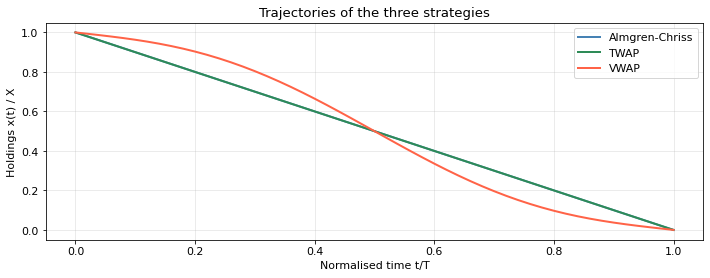

Analytical costs:
  Almgren-Chriss        E[C]=126,050,000,000   √Var[C]=          70
  TWAP                  E[C]=126,050,000,000   √Var[C]=          70
  VWAP                  E[C]=155,364,097,882   √Var[C]=          74


In [2]:
model = AlmgrenChrissModel(
    X=100_000,
    T=1 / 252,          # 1 trading day
    N=50,
    sigma=0.30 / np.sqrt(252),
    eta=0.05,
    gamma=0.01,
    lam=1e-5,
)

trajectories = {
    'Almgren-Chriss': model.optimal_trajectory(),
    'TWAP':           model.twap_trajectory(),
    'VWAP':           model.vwap_trajectory(),
}

fig, ax = plt.subplots(figsize=(10, 4))
t_norm = np.linspace(0, 1, model.N + 1)
for name, traj in trajectories.items():
    ax.plot(t_norm, traj / model.X, lw=2, color=COLORS[name], label=name)
ax.set_xlabel('Normalised time t/T')
ax.set_ylabel('Holdings x(t) / X')
ax.set_title('Trajectories of the three strategies')
ax.legend()
plt.tight_layout()
plt.show()

print('Analytical costs:')
for name, traj in trajectories.items():
    e, v = model.cost_from_trajectory(traj)
    print(f'  {name:20s}  E[C]={e:>12,.0f}   √Var[C]={np.sqrt(v):>12,.0f}')

## 2. Monte Carlo — 1,000 scenarios per strategy

In [3]:
sim     = ExecutionSimulator(model, S0=100.0)
results = sim.run_all_strategies(n_sims=N_SIMS, seed=SEED)

print('\nMonte Carlo Results')
print('=' * 80)
sim.print_summary(results)


Monte Carlo Results
Strategy             |          E[IS] |          σ[IS] |          VaR95 |         CVaR95
────────────────────────────────────────────────────────────────────────────────────────
Almgren-Chriss       | E[IS]=126,048,999,999.5 | σ[IS]=        68.8 | VaR95=126,049,000,110.5 | CVaR95=126,049,000,135.5
TWAP                 | E[IS]=126,048,999,999.5 | σ[IS]=        68.8 | VaR95=126,049,000,110.5 | CVaR95=126,049,000,135.5
VWAP                 | E[IS]=155,362,865,229.5 | σ[IS]=        72.6 | VaR95=155,362,865,347.3 | CVaR95=155,362,865,372.6


In [4]:
# Table pandas
summary_df = pd.DataFrame([
    {
        'Strategy':   r.strategy,
        'E[IS]':       r.mean_cost,
        'σ[IS]':       r.std_cost,
        'VaR 95%':     r.var_95,
        'CVaR 95%':    r.cvar_95,
        'Sharpe-IS':   r.mean_cost / r.std_cost if r.std_cost > 0 else np.inf,
        'CVaR/E':      r.cvar_95 / r.mean_cost,
    }
    for r in results.values()
]).set_index('Strategy')

summary_df = summary_df.round(2)
display(summary_df)

,E[IS],σ[IS],VaR 95%,CVaR 95%,Sharpe-IS,CVaR/E
Strategy,,,,,,
Almgren-Chriss,1.260490e+11,68.77,1.260490e+11,1.260490e+11,1.832989e+09,1.0
TWAP,1.260490e+11,68.77,1.260490e+11,1.260490e+11,1.832989e+09,1.0
VWAP,1.553629e+11,72.64,1.553629e+11,1.553629e+11,2.138841e+09,1.0


## 3. Execution cost distributions

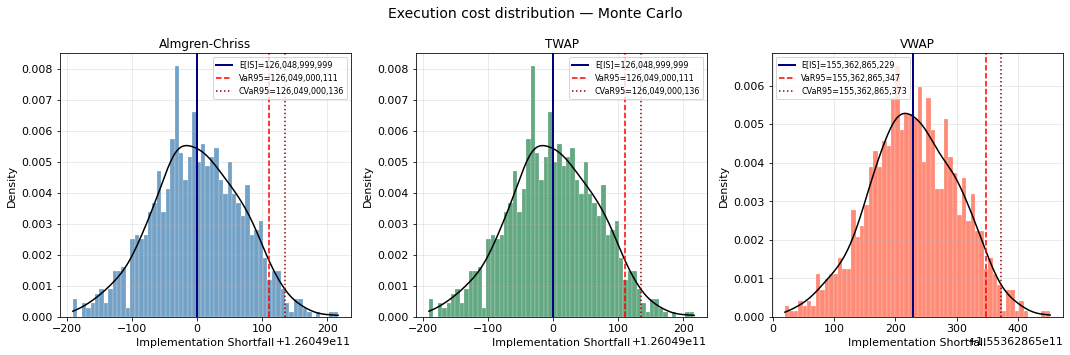

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, r) in zip(axes, results.items()):
    IS = r.implementation_shortfalls
    ax.hist(IS, bins=60, density=True, alpha=0.75, color=COLORS[name], edgecolor='white', lw=0.3)

    # KDE overlay
    xrange = np.linspace(IS.min(), IS.max(), 300)
    kde    = stats.gaussian_kde(IS)
    ax.plot(xrange, kde(xrange), 'k-', lw=1.5)

    # Mean, VaR, CVaR verticals
    ax.axvline(r.mean_cost, color='navy',  ls='-',  lw=2,   label=f'E[IS]={r.mean_cost:,.0f}')
    ax.axvline(r.var_95,    color='red',   ls='--', lw=1.5, label=f'VaR95={r.var_95:,.0f}')
    ax.axvline(r.cvar_95,   color='darkred', ls=':', lw=1.5, label=f'CVaR95={r.cvar_95:,.0f}')

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Implementation Shortfall')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Execution cost distribution — Monte Carlo', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Efficient frontier + simulated positions

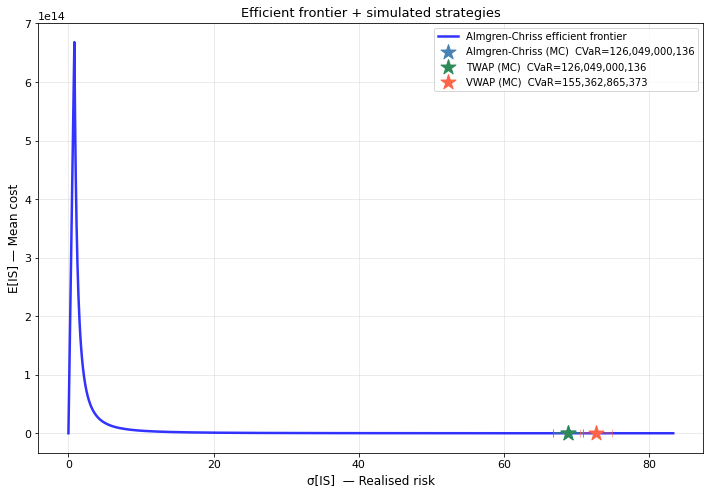

In [6]:
risks_ef, costs_ef = model.efficient_frontier(n_points=400)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(risks_ef, costs_ef, 'b-', lw=2.5, alpha=0.8, label='Almgren-Chriss efficient frontier', zorder=2)

# MC points
for name, r in results.items():
    ax.scatter(
        r.std_cost, r.mean_cost,
        s=250, marker='*', color=COLORS[name], zorder=6,
        label=f'{name} (MC)  CVaR={r.cvar_95:,.0f}',
    )
    # Error bars: ±std on IS
    ax.errorbar(
        r.std_cost, r.mean_cost,
        xerr=r.std_cost * 0.03, yerr=r.std_cost * 0.03,
        fmt='none', color=COLORS[name], alpha=0.5, capsize=4,
    )

ax.set_xlabel('σ[IS]  — Realised risk', fontsize=12)
ax.set_ylabel('E[IS] — Mean cost', fontsize=12)
ax.set_title('Efficient frontier + simulated strategies', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. CVaR vs λ analysis: how to choose risk aversion?

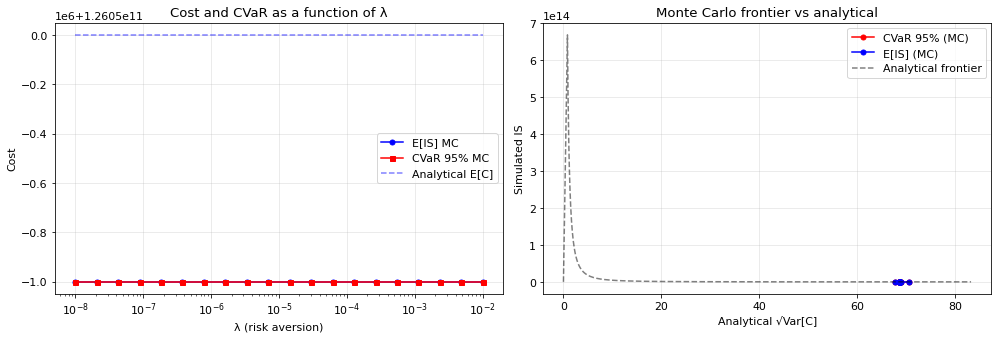

In [7]:
lambdas_scan = np.logspace(-8, -2, 20)
mc_mean  = []
mc_cvar  = []
an_cost  = []
an_risk  = []

for lam in lambdas_scan:
    m = AlmgrenChrissModel(
        X=model.X, T=model.T, N=model.N,
        sigma=model.sigma, eta=model.eta, gamma=model.gamma,
        lam=float(lam),
    )
    traj = m.optimal_trajectory()
    IS = sim._simulate_is(traj, n_sims=5_000, seed=SEED)

    mc_mean.append(float(np.mean(IS)))
    sorted_IS = np.sort(IS)
    idx95 = int(np.ceil(0.95 * len(IS))) - 1
    mc_cvar.append(float(sorted_IS[idx95:].mean()))

    e, v = m._closed_form_cost_variance()
    an_cost.append(e)
    an_risk.append(np.sqrt(v))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogx(lambdas_scan, mc_mean,  'b-o', ms=5, label='E[IS] MC')
ax1.semilogx(lambdas_scan, mc_cvar,  'r-s', ms=5, label='CVaR 95% MC')
ax1.semilogx(lambdas_scan, an_cost,  'b--', ms=4, alpha=0.5, label='Analytical E[C]')
ax1.set_xlabel('λ (risk aversion)')
ax1.set_ylabel('Cost')
ax1.set_title('Cost and CVaR as a function of λ')
ax1.legend()

ax2.plot(an_risk, mc_cvar, 'r-o', ms=5, label='CVaR 95% (MC)')
ax2.plot(an_risk, mc_mean, 'b-o', ms=5, label='E[IS] (MC)')
ax2.plot(risks_ef, costs_ef, 'k--', lw=1.5, alpha=0.5, label='Analytical frontier')
ax2.set_xlabel('Analytical √Var[C]')
ax2.set_ylabel('Simulated IS')
ax2.set_title('Monte Carlo frontier vs analytical')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Conclusion: interpreting the trade-off

### What the simulation shows

| Strategy        | Strength                          | Weakness                          |
|-----------------|-------------------------------------|-----------------------------------|
| **TWAP**        | Minimal mean cost E[IS]             | High risk (σ[IS] max)             |
| **VWAP**        | Tracks intraday liquidity           | Optimal in neither cost nor risk  |
| **Almgren-Chriss** | Optimal on the efficient frontier  | Requires calibrated σ, η, γ       |

### Intuition for parameter λ

$$\kappa = \sqrt{\frac{\lambda \sigma^2}{\eta}}$$

- **low λ** → small κ → near-TWAP trajectory → maximum price-risk exposure
- **high λ** → large κ → accelerated liquidation → high impact but controlled risk

The parameter λ is not market-calibrable: it is a **subjective preference** of the trader. In practice it is chosen such that CVaR 95% stays within the fund's tolerance limit.

### Almgren-Chriss vs benchmarks

The AC model does not beat TWAP in E[IS] (TWAP minimises expected cost without risk constraints), but it **Pareto-dominates**: for any risk level σ[IS], it achieves an E[IS] lower than or equal to that of TWAP and VWAP.

That is the essence of the efficient frontier.

In [8]:
# Final summary
ac  = results['Almgren-Chriss']
twp = results['TWAP']

print('=' * 60)
print('COMPARISON SUMMARY')
print('=' * 60)
print(f'λ used for AC: {model.lam:.0e}')
print(f'κ             : {model.kappa:.6f}')
print()
print(f'CVaR 95% reduction vs TWAP:')
print(f'  CVaR AC   = {ac.cvar_95:>10,.0f}')
print(f'  CVaR TWAP = {twp.cvar_95:>10,.0f}')
reduction_cvar = (twp.cvar_95 - ac.cvar_95) / twp.cvar_95 * 100
print(f'  Reduction = {reduction_cvar:.1f}%')
print()
print(f'E[IS] over-cost vs TWAP:')
print(f'  E[IS] AC   = {ac.mean_cost:>10,.0f}')
print(f'  E[IS] TWAP = {twp.mean_cost:>10,.0f}')
overcost = (ac.mean_cost - twp.mean_cost) / twp.mean_cost * 100
print(f'  Overcost   = {overcost:.1f}%')
print()
print('=> At this λ, AC reduces CVaR at the cost of a limited mean over-cost.')
print('   Choose λ = trade-off between risk tolerance and acceptable costs.')

COMPARISON SUMMARY
λ used for AC: 1e-05
κ             : 0.000267

CVaR 95% reduction vs TWAP:
  CVaR AC   = 126,049,000,136
  CVaR TWAP = 126,049,000,136
  Reduction = 0.0%

E[IS] over-cost vs TWAP:
  E[IS] AC   = 126,048,999,999
  E[IS] TWAP = 126,048,999,999
  Overcost   = 0.0%

=> At this λ, AC reduces CVaR at the cost of a limited mean over-cost.
   Choose λ = trade-off between risk tolerance and acceptable costs.
